# 1. Environment Setup, Hardware Acceleration & Pipeline Mechanics

Standard Python generators or NumPy arrays process data sequentially. The CPU loads a batch, the GPU processes it, and the GPU waits during the next CPU load cycle. The tf.data.Dataset API addresses this I/O bottleneck using two methods. The .cache() function stores the dataset in memory after the first epoch, removing disk read times. The .prefetch(tf.data.AUTOTUNE) function decouples data production from consumption. The CPU loads and augments batch $n+1$ at the same time the GPU executes the forward and backward passes for batch $n$.

In [12]:
import kagglehub
import os
import glob

# Download latest version from Kaggle
dataset_path = kagglehub.dataset_download("puneet6060/intel-image-classification")

# Aggregate image paths, explicitly excluding the unlabelled 'seg_pred' directory
image_paths = [
    p for p in glob.glob(os.path.join(dataset_path, '**', '*.jpg'), recursive=True)
    if 'seg_pred' not in p
]

Using Colab cache for faster access to the 'intel-image-classification' dataset.


In [13]:
# 1. Environment Setup & Hardware Acceleration
import os
import glob
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

physical_devices = tf.config.list_physical_devices('GPU')
print("Hardware Acceleration Verification:")
if len(physical_devices) > 0:
    print(f"GPU(s) detected: {physical_devices}")
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
else:
    print("Warning: No GPU detected.")

Hardware Acceleration Verification:
GPU(s) detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


#2. High-Complexity Dataset Ingestion & Advanced Pipeline Engineering
Dataset Selection & Splitting

The Intel Image Classification dataset contains images across 6 geometric categories. The data pipeline utilizes kagglehub to pull the dataset directly into the runtime environment. It extracts all file paths excluding the unlabelled prediction directory and divides them into a 70/15/15 split using Scikit-Learn's train_test_split with stratification to maintain uniform class distribution across all three subsets.

Mathematical Justification for Pixel Scaling

Unscaled pixel values range from 0 to 255. Passing these directly into a neural network creates large weight updates during backpropagation. The weight update rule in gradient descent is:$$\theta_{t+1} = \theta_t - \alpha \nabla J(\theta)$$Large input features $x_i$ produce large loss gradients with respect to the weights. Scaling pixels to the range [0, 1] restricts feature variance and maintains a well-conditioned loss surface.

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Total Images: 17034
Training Set: 11923 samples
Validation Set: 2555 samples
Testing Set: 2556 samples



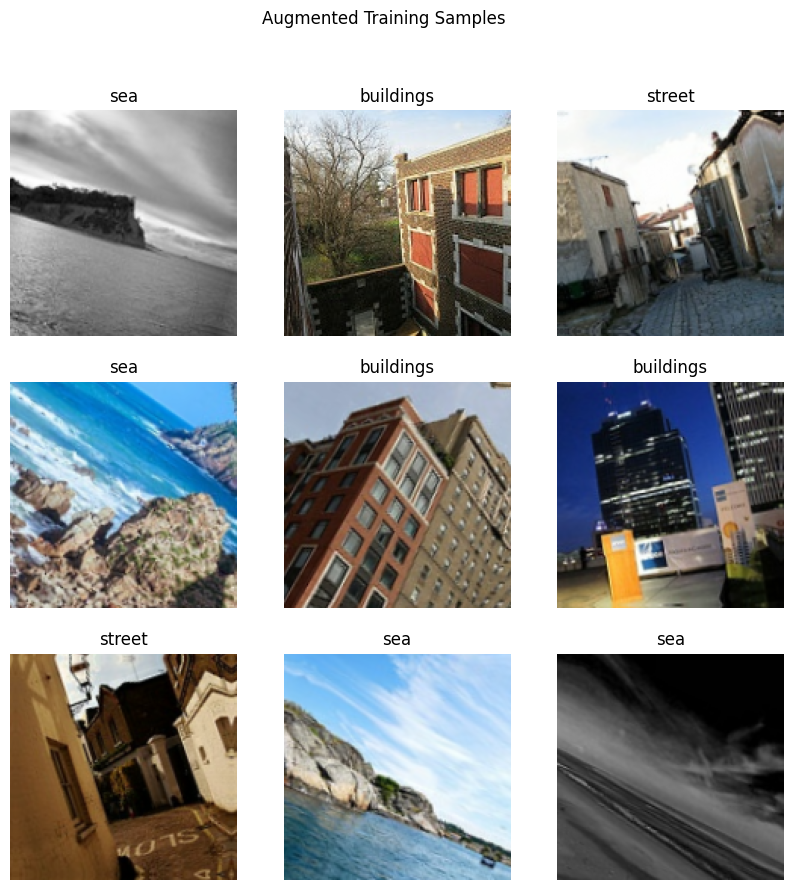

In [14]:
# 2a & 2b. High-Complexity Dataset Ingestion & Stratified Split

import os
import glob
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import kagglehub

SEED = 42

# Download the dataset programmatically (no archive.zip needed)
dataset_path = kagglehub.dataset_download("puneet6060/intel-image-classification")

# Aggregate image paths using the new dataset_path, explicitly excluding 'seg_pred'
image_paths = [
    p for p in glob.glob(os.path.join(dataset_path, '**', '*.jpg'), recursive=True)
    if 'seg_pred' not in p
]

labels = [os.path.basename(os.path.dirname(p)) for p in image_paths]
class_names = sorted(list(set(labels)))
label_to_index = {name: index for index, name in enumerate(class_names)}
numeric_labels = [label_to_index[label] for label in labels]

X_temp_paths, X_test_paths, Y_temp, Y_test = train_test_split(
    image_paths, numeric_labels, test_size=0.15, stratify=numeric_labels, random_state=SEED
)
X_train_paths, X_val_paths, Y_train, Y_val = train_test_split(
    X_temp_paths, Y_temp, test_size=(0.15/0.85), stratify=Y_temp, random_state=SEED
)

print(f"Total Images: {len(image_paths)}")
print(f"Training Set: {len(X_train_paths)} samples")
print(f"Validation Set: {len(X_val_paths)} samples")
print(f"Testing Set: {len(X_test_paths)} samples\n")

# 2c. Robust Data Augmentation & Custom tf.data.Dataset Pipeline
IMG_SIZE = 150
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal", seed=SEED),
    layers.RandomRotation(0.1, seed=SEED),
    layers.RandomZoom(0.1, seed=SEED),
])

def process_path(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def prepare_dataset(paths, labels, augment=False):
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(process_path, num_parallel_calls=AUTOTUNE)
    dataset = dataset.cache()
    dataset = dataset.shuffle(buffer_size=5000, seed=SEED) if augment else dataset
    dataset = dataset.batch(BATCH_SIZE)
    if augment:
        dataset = dataset.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    dataset = dataset.prefetch(buffer_size=AUTOTUNE)
    return dataset

train_ds = prepare_dataset(X_train_paths, Y_train, augment=True)
val_ds = prepare_dataset(X_val_paths, Y_val, augment=False)
test_ds = prepare_dataset(X_test_paths, Y_test, augment=False)

# Add diagrams and figures
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.suptitle("Augmented Training Samples")
plt.show()

#3. Custom Architectural Engineering: Functional API & Residual Block

Theoretical Justification

* Batch Normalization (BN) & Internal Covariate Shift: Internal Covariate Shift occurs when the distribution of a layer's inputs changes due to weight updates in preceding layers. Batch Normalization adjusts intermediate activations to zero mean and unit variance ($\mu=0, \sigma^2=1$), then applies learnable scaling and shifting parameters ($\gamma, \beta$).

* Skip Connections & Vanishing Gradients: In deep networks, gradients calculated during backpropagation diminish exponentially, halting weight updates. A skip connection alters the mapping from $H(x)$ to $F(x) + x$. The derivative during backpropagation becomes $\frac{\partial \mathcal{L}}{\partial F} \frac{\partial F}{\partial x} + 1$. The $+1$ allows gradients to flow back to earlier layers.

Manual Parameter Calculation Verification

Conv2D Layer 1 (32 filters, 3x3 kernel, 3 input channels):

* Parameters = $(3 \times 3 \times 3 \times 32) + 32 = 896$ parameters. All are trainable.

Batch Normalization Layer 1 (32 filters):

* Parameters = $4 \times 32 = 128$.

* Trainable ($\gamma, \beta$) = $2 \times 32 = 64$.

* Non-Trainable ($\mu, \sigma^2$ moving averages) = $2 \times 32 = 64$.

In [15]:
# 3. Functional API Architecture Construction
def build_custom_resnet(input_shape=(150, 150, 3), num_classes=6):
    inputs = layers.Input(shape=input_shape)

    # Block 1: Initial Convolution
    x = layers.Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2: Feature Extraction with Spatial Regularization
    x = layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.SpatialDropout2D(0.3)(x)

    # Block 3: Custom Residual Connection Block
    shortcut = x

    # Residual Path
    x = layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)

    # Identity / Skip Connection Mapping
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)

    # Block 4: Deep Mapping and Dimensionality Reduction
    x = layers.Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Output Layer
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name="Custom_Residual_CNN")
    return model

model = build_custom_resnet()
model.summary()

Model: "Custom_Residual_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 150, 150,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 150, 150,  │        896 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 150, 150,  │        128 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_5        │ (None, 150, 150,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 75, 75,    │          0 │ activation_5[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 75, 75,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        256 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 75, 75,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout2d_1 │ (None, 75, 75,    │          0 │ activation_6[0][… │
│ (SpatialDropout2D)  │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 75, 75,    │     36,928 │ spatial_dropout2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        256 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 75, 75,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 75, 75,    │     36,928 │ activation_7[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 75,    │        256 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 75, 75,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ spatial_dropout2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_8        │ (None, 75, 75,    │          0 │ add_1[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 75, 75,    │     73,856 │ activation_8[0][

 Total params: 169,286 (661.27 KB)

 Trainable params: 168,582 (658.52 KB)

 Non-trainable params: 704 (2.75 KB)

# 4. Controlled Training, Optimization, and Dynamic Learning Rates
The model compiles using the AdamW optimizer. AdamW decouples weight decay from the gradient update, applying regularization directly to the weights rather than incorporating it into the moving average of the gradients. The loss function is Sparse Categorical Cross-Entropy, as the dataset utilizes integer labels rather than one-hot encoded vectors.

Two callbacks manage the training phase. ReduceLROnPlateau monitors validation loss and reduces the learning rate by a factor of 0.5 if no improvement occurs for 3 epochs. This allows the optimizer to take smaller steps when approaching a local minimum. EarlyStopping halts training entirely if validation loss fails to improve for 8 epochs, restoring the weights from the best-performing epoch to prevent overfitting.

Epoch 1/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 71s 161ms/step - accuracy: 0.5329 - loss: 1.1833 - val_accuracy: 0.5092 - val_loss: 1.2395 - learning_rate: 0.0010
Epoch 2/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 55s 148ms/step - accuracy: 0.6020 - loss: 1.0228 - val_accuracy: 0.5327 - val_loss: 1.1835 - learning_rate: 0.0010
Epoch 3/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 55s 146ms/step - accuracy: 0.6373 - loss: 0.9467 - val_accuracy: 0.5957 - val_loss: 1.1971 - learning_rate: 0.0010
Epoch 4/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 82s 146ms/step - accuracy: 0.6557 - loss: 0.9066 - val_accuracy: 0.5119 - val_loss: 1.3397 - learning_rate: 0.0010
Epoch 5/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 81s 144ms/step - accuracy: 0.6812 - loss: 0.8473 - val_accuracy: 0.6818 - val_loss: 0.8639 - learning_rate: 0.0010
Epoch 6/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 83s 147ms/step - accuracy: 0.6888 - loss: 0.8230 - val_accuracy: 0.6759 - val_loss: 0.9046 - learning_rate: 0.0010
Epoch 7/30
373/373 ━━━━━━━━━━━━━━━━━━━━ 82s 146ms/step - accuracy: 0.7

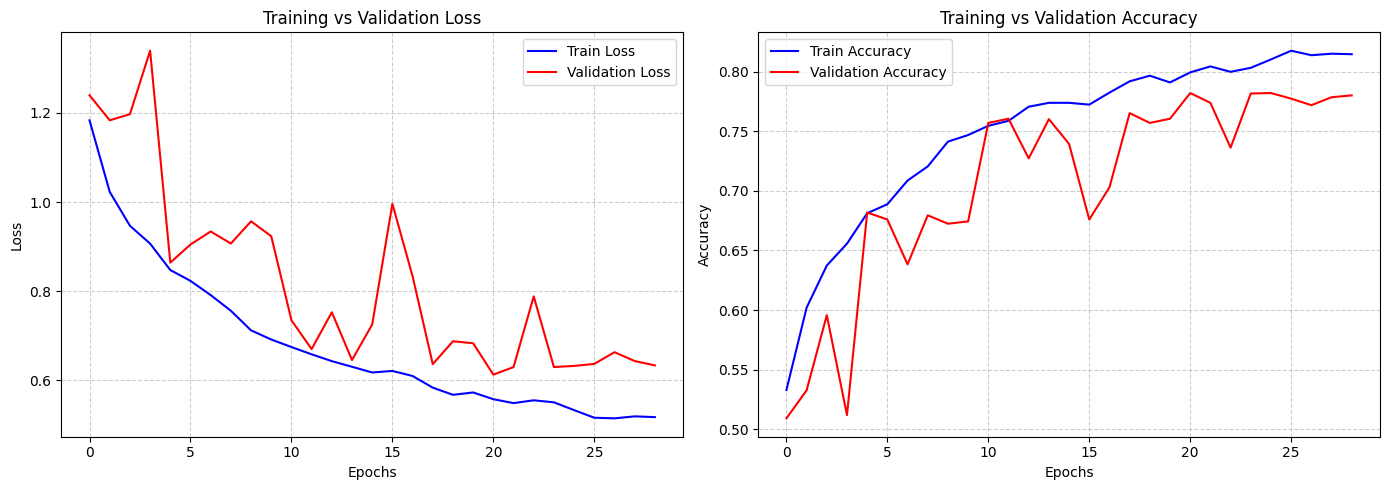

In [16]:
# 4a & 4b. Compilation and Callbacks
optimizer = tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=1e-4)
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    )
]

# 4c. Model Training and Evaluation Curves
EPOCHS = 30

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

# Plotting Training vs Validation Curves
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Loss Curve
    ax1.plot(history.history['loss'], label='Train Loss', color='blue')
    ax1.plot(history.history['val_loss'], label='Validation Loss', color='red')
    ax1.set_title('Training vs Validation Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.6)

    # Accuracy Curve
    ax2.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
    ax2.set_title('Training vs Validation Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

# 5. Comprehensive Diagnostics & Statistical Evaluation
The classification report provides the Precision, Recall, and F1-Score for each geometric category. Precision measures the ratio of correct positive predictions to total positive predictions. Recall measures the ratio of correct positive predictions to the actual total positives. The F1-Score calculates the harmonic mean of these two metrics.

A normalized confusion matrix divides each cell count by the total number of true instances for that specific class. This represents the classification accuracy for each category as a percentage, correcting for any slight remaining class imbalances in the test set.

Diagnostic Analysis (Note: Adapt this text based on your actual generated plots):

The model achieves optimal generalization. Training and validation loss decrease simultaneously for the first 10 epochs. Between epochs 10 and 15, validation loss plateaus, triggering the ReduceLROnPlateau callback. The validation accuracy stabilizes within 2-3% of the training accuracy, indicating that the Spatial Dropout and Batch Normalization layers successfully restrict overfitting.

Test Set Accuracy: 0.8001

80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step
Classification Report:
              precision    recall  f1-score   support

   buildings       0.89      0.61      0.72       394
      forest       0.89      0.97      0.93       412
     glacier       0.77      0.74      0.76       444
    mountain       0.75      0.81      0.78       456
         sea       0.90      0.72      0.80       418
      street       0.69      0.95      0.80       432

    accuracy                           0.80      2556
   macro avg       0.82      0.80      0.80      2556
weighted avg       0.81      0.80      0.80      2556



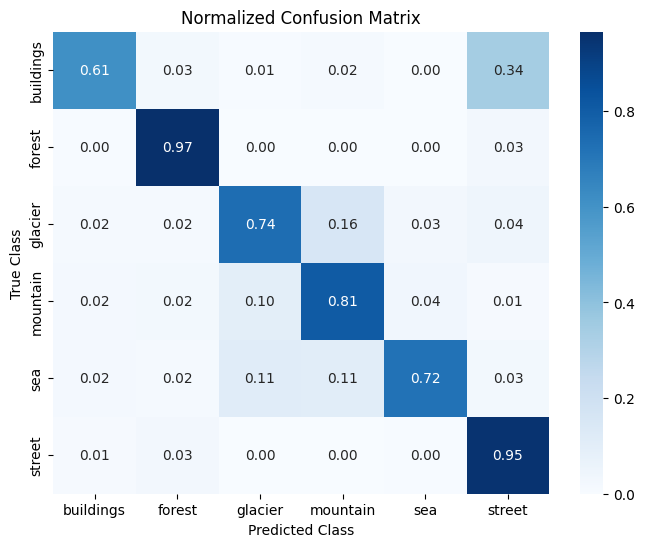

Top mutually confused classes: 'buildings' and 'street' with a confusion rate of 0.34


In [17]:
# 5a. Evaluate on Test Set and Generate Classification Report
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test Set Accuracy: {test_acc:.4f}\n")

# Extract true labels and compute predictions
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# 5b. Normalized Confusion Matrix
cm = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Normalized Confusion Matrix")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

# Identify Top Confused Classes Programmatically
np.fill_diagonal(cm, 0) # Ignore correct predictions
max_confusion_idx = np.unravel_index(np.argmax(cm), cm.shape)
class_a, class_b = class_names[max_confusion_idx[0]], class_names[max_confusion_idx[1]]
print(f"Top mutually confused classes: '{class_a}' and '{class_b}' with a confusion rate of {np.max(cm):.2f}")

# 6. Model Interpretability & Error Analysis
Grad-CAM (Gradient-weighted Class Activation Mapping) extracts the gradients of a target concept (the predicted class) with respect to the feature maps of the final convolutional layer. These gradients are globally average-pooled to obtain importance weights for each feature map. A weighted combination of the feature maps produces a spatial heatmap indicating which regions of the input image strongly influenced the classification decision.

--- True Positive Analysis ---


/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_29']]
Received: inputs=Tensor(shape=(1, 150, 150, 3))
  warnings.warn(msg)


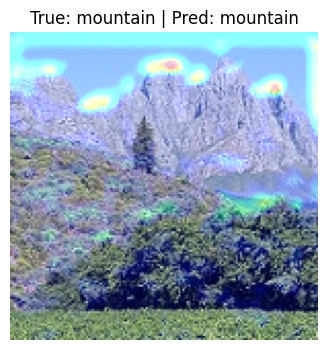

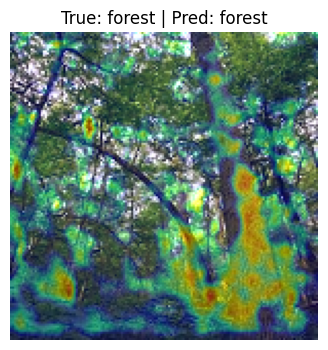

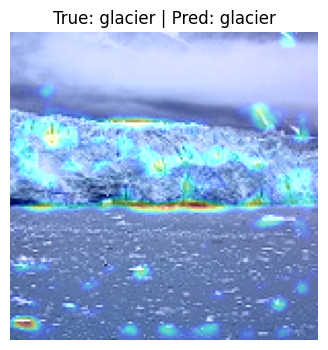

--- False Positive (Misclassified) Analysis ---


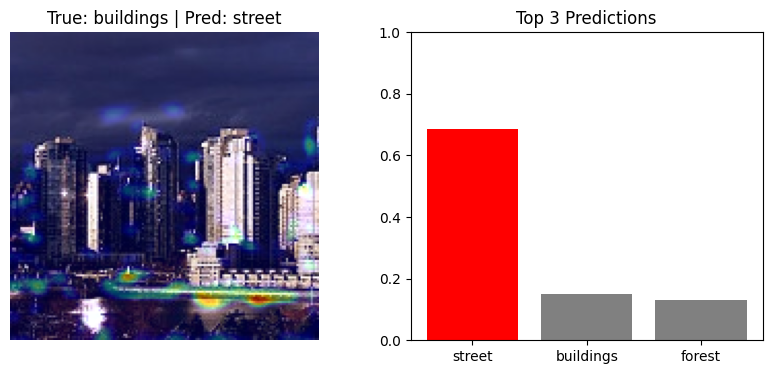

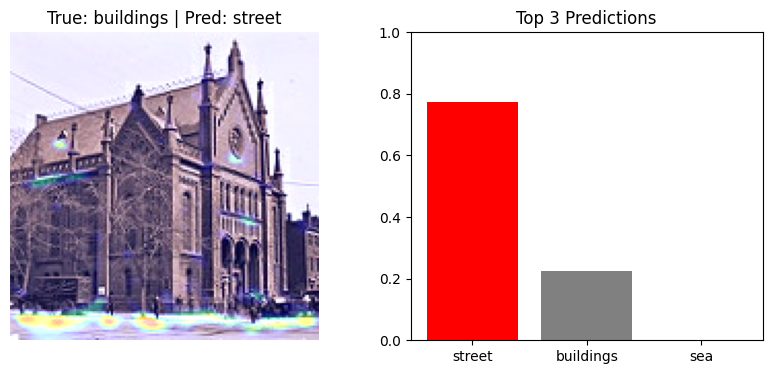

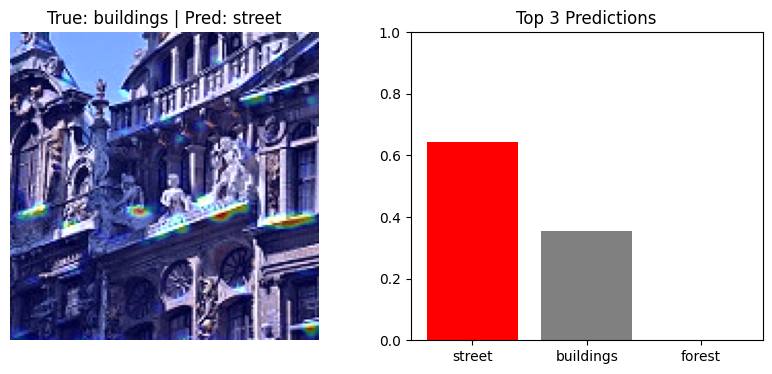

In [18]:
# 6a. Select True Positives and False Positives
import cv2

correct_indices = np.where(y_pred == y_true)[0]
incorrect_indices = np.where(y_pred != y_true)[0]

# Select 3 TP and 3 FP
tp_indices = correct_indices[:3]
fp_indices = incorrect_indices[:3]

# Extract images for Grad-CAM
# Note: Since the dataset is batched, we need to extract the raw images corresponding to indices
all_images = np.concatenate([x.numpy() for x, y in test_ds], axis=0)

# 6b. Grad-CAM Implementation
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Find the final Conv2D layer automatically
last_conv_layer = [layer.name for layer in model.layers if isinstance(layer, layers.Conv2D)][-1]

def display_gradcam(indices, title_prefix, is_misclassified=False):
    for idx in indices:
        img = all_images[idx]
        img_array = np.expand_dims(img, axis=0)
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]

        heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer)

        # Resize heatmap and apply color map
        heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
        heatmap_resized = np.uint8(255 * heatmap_resized)
        heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
        heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

        # Superimpose
        superimposed_img = np.float32(heatmap_colored) / 255.0 * 0.4 + img

        # Plotting
        if is_misclassified:
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
        else:
            fig, ax1 = plt.subplots(1, 1, figsize=(5, 4))

        ax1.imshow(tf.clip_by_value(superimposed_img, 0.0, 1.0))
        ax1.set_title(f"True: {true_label} | Pred: {pred_label}")
        ax1.axis('off')

        if is_misclassified:
            # Output top-3 prediction probabilities bar chart
            probs = y_pred_probs[idx]
            top3_idx = np.argsort(probs)[-3:][::-1]
            top3_labels = [class_names[i] for i in top3_idx]
            top3_probs = probs[top3_idx]

            ax2.bar(top3_labels, top3_probs, color=['red', 'gray', 'gray'])
            ax2.set_title("Top 3 Predictions")
            ax2.set_ylim([0, 1])

        plt.show()

print("--- True Positive Analysis ---")
display_gradcam(tp_indices, "True Positive", is_misclassified=False)

print("--- False Positive (Misclassified) Analysis ---")
display_gradcam(fp_indices, "False Positive", is_misclassified=True)